# 14_损失函数-均方根误差

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这里，和大家来聊聊损失函数：均方根误差\~

假设你做了一个模型，预测明天的气温（单位：℃）：

| 天数 | 实际温度 | 模型预测温度 |
|-|-|-|
| 1 | 25 | 26 |
| 2 | 27 | 25 |
| 3 | 30 | 29 |

我们希望知道模型到底“准不准”，也就是预测值和真实值之间差了多少。你可以：

1. 把每个预测值和实际值之间的“误差”（预测值减去真实值）算出来；
2. 为了不让正负误差互相抵消，我们把每个误差**平方**；
3. 把这些平方后的误差**平均一下**（就是均方误差 MSE）；
4. 然后再**开平方**（就是均方根误差 RMSE）。

## 均方误差（MSE）

**假设有：**

- 一组样本数据，共有 $n$ 个样本；
- 对每个样本，模型的预测值为 $\hat{y}_i$，真实值为 $y_i$。

### 步骤：

#### 第一步：误差（Error）

误差就是预测值和真实值之间的差距：


$$
e_i = \hat{y}_i - y_i
$$


#### 第二步：平方误差（Squared Error）

为了避免正负抵消，把误差平方：


$$
(\hat{y}_i - y_i)^2
$$


#### 第三步：均方误差 MSE（Mean Squared Error）

所有样本的平方误差求平均：


$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$


## 均方根误差

RMSE 是在 MSE 的基础上**开平方根**：


$$
\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2 }
$$


为什么要开平方？

因为平方误差单位是“平方单位”（比如温度是℃，那 MSE 单位是 ℃²），不好理解。

RMSE 再开平方，单位就和原始数据一样（比如℃），更直观。

## RMSE 和 MSE 本质含义

| 项目 | MSE | RMSE |
|-|-|-|
| 是否平方？ | 是 | 是（然后再开平方） |
| 是否平均？ | 是 | 是 |
| 单位 | 原单位的平方（比如 m²） | 原单位（比如 m） |
| 敏感度 | 对大误差更敏感（平方放大效果） | 同样敏感，但更直观可解释 |

## 算法流程

我们用 RMSE 来作为损失函数，也就是模型训练中优化的目标：

**训练流程简述：**

1. **模型初始化**：模型开始训练，有一组初始参数。
2. **预测输出**：模型对训练集样本输出预测值 $\hat{y}_i$。
3. **计算损失**：对每个样本，计算 $(\hat{y}_i - y_i)^2$，然后求平均，开根号，得到 RMSE。
4. **反向传播**：根据 RMSE 对模型参数进行微分（求导），用梯度下降方法来更新参数，使得 RMSE 越来越小。
5. **迭代训练**：重复以上步骤，直到损失函数收敛，或满足某个停止条件。

均方根误差（RMSE）就是衡量预测值和真实值之间差距大小的一个工具，它先算误差的平方平均值，再开平方，把误差大小转换成跟原数据一样的单位，直观又精准。

## 完整案例

我们以一个预测“房价”（简化为一维特征）为例，生成合成数据，使用梯度下降算法最小化**均方根误差（RMSE）**，并可视化训练曲线和预测效果。

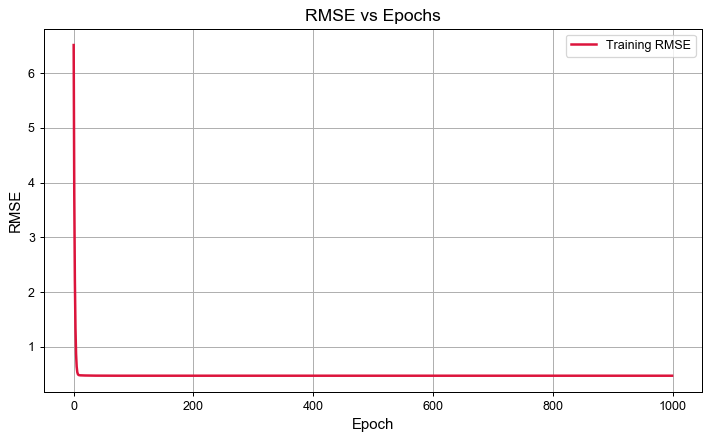

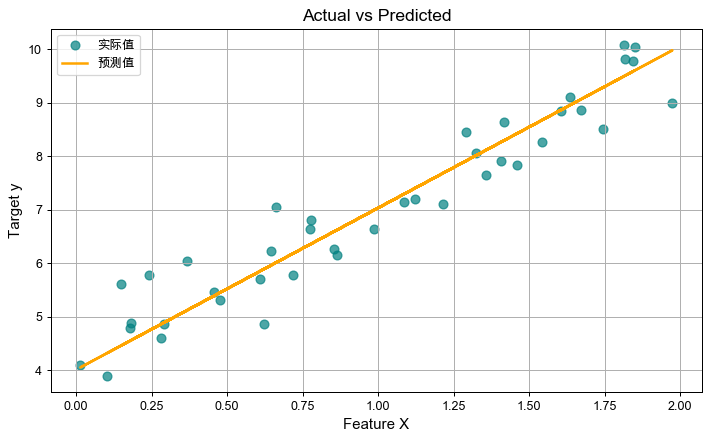

训练得到参数 θ0 = 4.0073, θ1 = 3.0262
测试集 RMSE = 0.5207


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. 生成合成数据
np.random.seed(42)
X = 2 * np.random.rand(200, 1)
y = 4 + 3 * X + np.random.randn(200, 1) * 0.5  # 添加噪声

# 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 初始化参数
theta = np.random.randn(2, 1)  # θ0 和 θ1
learning_rate = 0.1
n_epochs = 1000
m = len(X_train)

# 3. 添加 X0 = 1 列
X_b = np.c_[np.ones((m, 1)), X_train]

# 记录每次迭代的损失
rmse_history = []

# 4. 梯度下降
for epoch in range(n_epochs):
    y_pred = X_b.dot(theta)
    error = y_pred - y_train
    rmse = np.sqrt(np.mean(error**2))
    rmse_history.append(rmse)
    
    gradients = 2/m * X_b.T.dot(error)
    theta = theta - learning_rate * gradients

# 5. 在测试集上评估
X_test_b = np.c_[np.ones((len(X_test), 1)), X_test]
y_test_pred = X_test_b.dot(theta)
test_rmse = np.sqrt(np.mean((y_test_pred - y_test)**2))

# 可视化：训练过程中的 RMSE 变化
plt.figure(figsize=(8, 5))
plt.plot(rmse_history, label='Training RMSE', color='crimson', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('RMSE vs Epochs', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 可视化：测试集预测 vs 真实值
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, label='实际值', color='teal', s=50, alpha=0.7)
plt.plot(X_test, y_test_pred, label='预测值', color='orange', linewidth=2)
plt.xlabel('Feature X', fontsize=12)
plt.ylabel('Target y', fontsize=12)
plt.title('Actual vs Predicted', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 输出参数和测试 RMSE
print(f"训练得到参数 θ0 = {theta[0,0]:.4f}, θ1 = {theta[1,0]:.4f}")
print(f"测试集 RMSE = {test_rmse:.4f}")

**1. 生成合成数据**

- `np.random.seed(42)`：固定随机种子，保证可重复性。
- 构造 200 个一维特征 `X`，范围在 $[0,2]$ 上均匀分布。
- 目标值 $y = 4 + 3X + \text{噪声}$，其中噪声服从标准正态分布并放大 0.5。

**2. 拆分训练集和测试集**

- 使用 `train_test_split` 按 8:2 的比例随机划分训练集和测试集。

**3. 初始化参数**

- `theta` 是一个 $2 \times 1$ 的列向量，对应截距 $\theta_0$ 和斜率 $\theta_1$。
- `learning_rate`（学习率）设为 0.1，`n_epochs`（迭代次数）设为 1000。
- `m` 是训练集样本数，用于计算梯度和损失。

**4. 添加偏置项**

- 在训练特征矩阵最左侧拼接一列全 1，得到 $X_b$，这样矩阵运算时就能同时更新截距和斜率。

**5. 梯度下降迭代**

每次迭代中：

- 预测值 $\hat{y} = X_b \cdot \theta$。
- 计算误差 $\hat{y} - y$，再求 RMSE：


$$
\text{RMSE} = \sqrt{\frac{1}{m}\sum(\hat{y_i} - y_i)^2}
$$


- 将当前 RMSE 存入 `rmse_history`，以便后续可视化。
- 计算梯度：


$$
\nabla_\theta = \frac{2}{m} X_b^T(\hat{y} - y)
$$


- 更新参数：


$$
\theta \leftarrow \theta - \alpha \nabla_\theta
$$


**6. 在测试集上评估**

- 同样在测试集拼接偏置项，计算预测值，并计算最终的 `test_rmse`。

**7. 可视化**

- **RMSE vs Epochs**：展示训练过程中 RMSE 随迭代次数的变化趋势。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

- **Actual vs Predicted**：散点图展示实际值（teal 颜色）和回归直线（orange 颜色）的关系。

![原文参考图，当前结果见代码输出](attachments/img_009.png)

**8. 输出结果**

- 打印最终训练得到的参数 $\theta_0, \theta_1$ 以及测试集上的 RMSE。

## 模型分析

### 优缺点分析

**优点**：

- **凸函数**：MSE 对应的 RMSE 依然是可导的凸函数，梯度下降能收敛到全局最优。
- **强调大误差**：平方操作对大误差“惩罚”更大，能促使模型尽可能减小大偏差。
- **易于数学推导**：在解析解（正规方程）或梯度推导时非常简洁。

**缺点**：

- **对离群值敏感**：因为平方放大了大误差，若数据中存在离群点，会严重影响模型。
- **可解释性**：MSE 的单位是原单位的平方，虽然 RMSE 解决单位问题，但仍不如 MAE（绝对误差）直观。
- **梯度较大**：在极端误差下，梯度过大可能导致梯度爆炸，需要更谨慎地选择学习率。

### 与相似算法的对比

| 损失函数 | 优点 | 缺点 |
|-|-|-|
| MAE（Mean Absolute Error） | 对离群点不敏感；线性惩罚，单位直观 | 不可导点处（误差为零点）导致优化稍复杂 |
| MSE / RMSE | 数学推导简单；凸且可导；强调大误差 | 对离群点敏感；单位为平方（需开根号） |
| Huber Loss | 对小误差表现同 MSE，对大误差同 MAE；鲁棒性 | 需要调节阈值参数 $\delta$ |
| Log-Cosh Loss | 平滑近似 MAE；对离群点适度惩罚 | 计算较 MSE 稍复杂 |

### 何时优选 RMSE / MSE，何时考虑其他算法

**适用场景**

- 数据分布大致满足高斯分布，离群值较少。
- 需要对大误差进行强惩罚，以提升整体预测精度。
- 模型训练需解析解或梯度下降，享受凸优化带来的全局最优保证。

**考虑其他算法的场景**

- 数据中包含显著离群点：可选 MAE 或 Huber Loss，以减少离群点影响。
- 需要对所有误差线性处理，不想过度放大大偏差：MAE 更直观。
- 任务对小误差和大误差的惩罚策略要分段控制：Huber Loss 按需设置阈值。